# Lab 29 — Antenna Arrays and Beamforming: Planar Arrays, Squint, Direction Finding, Codebooks, Hybrid Precoding and LOS MIMO

**Companion to Chapter 19** (*MIMO and Antenna Arrays*). Lab 10 covers MIMO diversity, capacity and detection; this lab is
about the array itself, the part of MIMO that millimetre-wave 5G turned into hardware.
**Time needed:** about 2 hours. **Difficulty:** core to advanced.

A 28 GHz base-station panel is a matchbox-sized grid of 64 patches, each with its own amplifier and phase shifter; a phone
has a few such modules in its frame. Together they buy the 20–30 dB of gain that makes millimetre waves usable. This lab
builds that panel and uses it: it computes the beam and the EIRP, shows why phase shifters squint across a wide band, finds
signal directions with MUSIC and MVDR, sweeps NR's SSB beams and picks a precoder from a codebook, factorises a precoder into
analog and digital parts with orthogonal matching pursuit, and spaces the antennas of a line-of-sight MIMO link. Helpers
follow Chapter 19's figure script and `commlib/mimo.py`.

### What you will learn
1. Compute the pattern, beamwidth, EIRP and link budget of a uniform planar array, with tapering and grating lobes.
2. See beam squint with phase shifters and its absence with true time delay.
3. Estimate directions of arrival with the Bartlett beamformer, MVDR (Capon) and MUSIC, and compare their resolution.
4. Sweep SSB beams, report the best one, and select a Type I precoder from a DFT codebook.
5. Design hybrid analog/digital precoders by orthogonal matching pursuit and compare them with SVD precoding.
6. Choose the antenna spacing of a line-of-sight MIMO link.

### Prerequisites
Lab 10 (MIMO). Steering vectors and array factor (Chapter 19, Section 19.6). Lab 22 (link budgets).

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Planar arrays: pattern, beamwidth, EIRP | yes |
| 2 | Beam squint: phase shifters vs true time delay | yes |
| 3 | Direction finding: Bartlett, MVDR, MUSIC | yes |
| 4 | Beam management: SSB sweep and a Type I codebook | yes |
| 5 | Hybrid precoding by orthogonal matching pursuit | yes |
| 6 | Line-of-sight MIMO | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import taylor
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=29, lab="29")
C0 = 299_792_458.0
cn = lambda r, shape: (r.standard_normal(shape) + 1j * r.standard_normal(shape)) / np.sqrt(2)


def upa_af_db(Nx, Ny, d, th0, ph0, taper_db=None, n=181):
    """Array factor (dB, normalised) of an Nx x Ny planar array in direction cosines (u, v),
    steered to (theta0, phi0). Elements spaced d wavelengths."""
    u = np.linspace(-1, 1, n)
    U, V = np.meshgrid(u, u)
    u0, v0 = np.sin(th0) * np.cos(ph0), np.sin(th0) * np.sin(ph0)
    wx = taylor(Nx, nbar=4, sll=taper_db) if taper_db else np.ones(Nx)
    wy = taylor(Ny, nbar=4, sll=taper_db) if taper_db else np.ones(Ny)
    ax_ = np.abs(np.exp(2j * np.pi * d * np.outer(U.ravel() - u0, np.arange(Nx))) @ wx)
    ay_ = np.abs(np.exp(2j * np.pi * d * np.outer(V.ravel() - v0, np.arange(Ny))) @ wy)
    af = (ax_ * ay_).reshape(U.shape) ** 2
    af[U ** 2 + V ** 2 > 1] = np.nan                       # outside visible space
    return u, lk.db(af / np.nanmax(af))

Lab 29 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 29


## 1. Planar arrays: pattern, beamwidth, EIRP

An $N_x \times N_y$ uniform planar array (UPA) is the product of two linear arrays. In direction cosines $u = \sin\theta\cos\phi$,
$v = \sin\theta\sin\phi$, its array factor is $|AF_x(u)|^2|AF_y(v)|^2$; steering shifts the pattern to $(u_0, v_0)$ without
changing its shape. With $d = \lambda/2$ the half-power beamwidth is $\theta_{3\,\mathrm{dB}} \approx 101.5°/(N\cos\theta_0)$,
the directivity is about $10\log_{10}(N_xN_y)$ plus the element gain, and since every element has its own amplifier the EIRP
grows as $N^2$: $N$ times the power and $N$ times the gain. Chapter 19's worked example: an 8 × 8 panel at 28 GHz, 5 dBi
elements, 10 dBm per element.

### Interactive: the panel

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

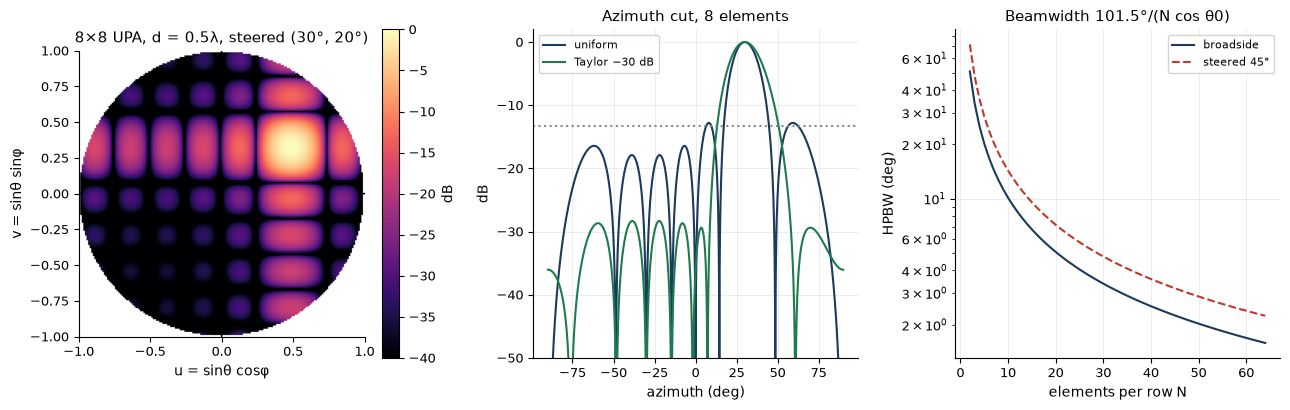

,
wavelength / element spacing,10.7 mm / 5.35 mm
panel size,43 mm square
HPBW at broadside,12.7°
array gain,23.1 dBi
total conducted power,28.1 dBm
EIRP,51.1 dBm
free-space loss at 200 m,107.4 dB
received power (9 dBi handset),-47.3 dBm
"noise, 400 MHz, NF 10 dB",-78.0 dBm
LOS SNR,30.7 dB


In [3]:
def upa_demo(N=8, steer_az=30.0, steer_el=20.0, d=0.5, taper_db=0.0, fc_ghz=28.0, p_el_dbm=10.0, g_el=5.0, dist=200.0):
    th0 = np.deg2rad(np.hypot(steer_az, steer_el)); ph0 = np.arctan2(np.deg2rad(steer_el), np.deg2rad(steer_az))
    u, af = upa_af_db(N, N, d, th0, ph0, taper_db or None)
    f, ax = lk.fig((13, 4.2), 1, 3, gridspec_kw=dict(width_ratios=[1.1, 1, 1]))
    im = ax[0].imshow(af, extent=[-1, 1, -1, 1], origin="lower", vmin=-40, vmax=0, cmap="magma")
    ax[0].set_xlabel("u = sinθ cosφ"); ax[0].set_ylabel("v = sinθ sinφ"); ax[0].grid(False); plt.colorbar(im, ax=ax[0], label="dB")
    ax[0].set_title(f"{N}×{N} UPA, d = {d:g}λ, steered ({steer_az:g}°, {steer_el:g}°)")
    th = np.deg2rad(np.linspace(-90, 90, 1801))
    for (w, lab, col) in [(cl.ula_steering(N, np.deg2rad(steer_az), d)[:, 0], "uniform", lk.NAVY),
                          (cl.ula_steering(N, np.deg2rad(steer_az), d)[:, 0] * taylor(N, nbar=4, sll=30), "Taylor −30 dB", lk.GREEN)]:
        ax[1].plot(np.rad2deg(th), cl.array_factor_db(w, th, d), color=col, label=lab)
    ax[1].axhline(-13.26, color=lk.GRAY, ls=":"); ax[1].set_ylim(-50, 2); ax[1].legend(fontsize=8)
    ax[1].set_xlabel("azimuth (deg)"); ax[1].set_ylabel("dB"); ax[1].set_title(f"Azimuth cut, {N} elements")
    Ns = np.arange(2, 65)
    ax[2].plot(Ns, 101.5 / Ns, color=lk.NAVY, label="broadside")
    ax[2].plot(Ns, 101.5 / (Ns * np.cos(np.deg2rad(45))), "--", color=lk.RED, label="steered 45°")
    ax[2].set_yscale("log"); ax[2].set_xlabel("elements per row N"); ax[2].set_ylabel("HPBW (deg)"); ax[2].legend(fontsize=8)
    ax[2].set_title("Beamwidth 101.5°/(N cos θ0)")
    lk.show(f)
    lam = C0 / (fc_ghz * 1e9)
    Ntot = N * N
    gain = 10 * np.log10(Ntot) + g_el
    ptot = p_el_dbm + 10 * np.log10(Ntot)
    fspl = 20 * np.log10(4 * np.pi * dist / lam)
    prx = ptot + gain - fspl + 9.0
    noise = -174 + 10 * np.log10(400e6) + 10
    lk.table([["wavelength / element spacing", f"{lam * 1e3:.1f} mm / {d * lam * 1e3:.2f} mm"],
              ["panel size", f"{N * d * lam * 1e3:.0f} mm square"], ["HPBW at broadside", f"{101.5 / N:.1f}°"],
              ["array gain", f"{gain:.1f} dBi"], ["total conducted power", f"{ptot:.1f} dBm"], ["EIRP", f"{ptot + gain:.1f} dBm"],
              [f"free-space loss at {dist:g} m", f"{fspl:.1f} dB"], ["received power (9 dBi handset)", f"{prx:.1f} dBm"],
              ["noise, 400 MHz, NF 10 dB", f"{noise:.1f} dBm"], ["LOS SNR", f"{prx - noise:.1f} dB"]], ["", ""])

lk.interact(upa_demo, N=lk.islider(8, 2, 32, 1, "elements per side"), steer_az=lk.slider(30, -60, 60, 1, "steer azimuth (deg)"),
            steer_el=lk.slider(20, -60, 60, 1, "steer elevation (deg)"), d=lk.slider(0.5, 0.3, 1.2, 0.05, "spacing (λ)"),
            taper_db=lk.choice([0.0, 25.0, 35.0], 0.0, "Taylor taper sidelobe level (0 = none)"),
            fc_ghz=lk.choice([3.5, 28.0, 39.0, 140.0], 28.0, "carrier (GHz)"), p_el_dbm=lk.slider(10, 0, 30, 1, "power per element (dBm)"),
            g_el=lk.slider(5, 0, 8, 0.5, "element gain (dBi)"), dist=lk.slider(200, 10, 1000, 10, "link distance (m)"))

**What you should see.** The steered main lobe in $(u, v)$ space with the cross-shaped sidelobes of a rectangular grid. The
table reproduces Chapter 19's worked example: 10.7 mm wavelength, a 43 mm panel, 12.7° beams, 23.1 dBi, 28.1 dBm conducted,
EIRP 51.1 dBm, 107.4 dB of path loss at 200 m, −47.3 dBm received and an LOS SNR of about 31 dB (the chapter adds rounded
figures and quotes 51.2 and −47.2 dBm). Push the spacing above 0.5λ
while steered: **grating lobes** enter visible space (the bright copies in the $(u, v)$ map). The Taylor taper lowers the
sidelobes from −13.3 dB to −30 dB at the price of a wider beam.

### Try it yourself 1.1
What EIRP (dBm) does a 16 × 16 panel with 5 dBi elements and 4 dBm per element reach?

In [5]:
answer_1_1 = None
lk.check("1.1 EIRP of a 16x16 panel (dBm)", answer_1_1, 4 + 20 * np.log10(256) + 5, atol=0.1)

[TODO] 1.1 EIRP of a 16x16 panel (dBm): not attempted yet: replace the None with your answer

## 2. Beam squint: phase shifters vs true time delay

A phase shifter applies $2\pi f_0\tau_n$, the right phase only at the design frequency. At $f \ne f_0$ the beam points at
$\sin\theta = (f_0/f)\sin\theta_0$, i.e. $\Delta\theta \approx -\frac{f-f_0}{f_0}\tan\theta_0$: **beam squint**. It matters when the
aperture fill time $T_a = (N-1)d\sin\theta_0/c$ is comparable to $1/B$; the gain at $\theta_0$ falls by 3 dB at the band edges when
$B \approx 0.9/T_a$. Chapter 19: 64 elements at 28 GHz steered 45° have $T_a \approx 0.8$ ns, so about 1.1 GHz of bandwidth loses 3 dB
at its edges. **True time delay** (TTD), or a digital beamformer with a phase per subcarrier, has no squint.

### Interactive: array size and bandwidth

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

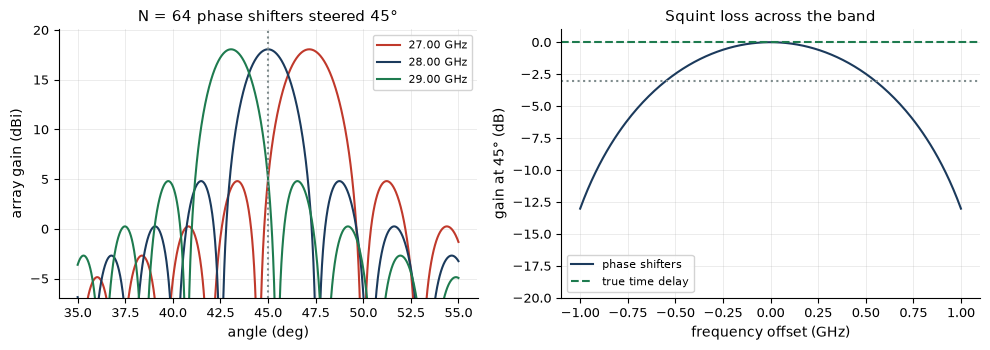

,
aperture fill time T_a,0.80 ns
3 dB bandwidth ≈ 0.9/T_a,1.13 GHz
"squint at band edge, Δθ ≈ (B/2f0) tanθ0",2.05°
beamwidth 101.5°/(N cosθ0),2.24°
loss at band edge,-13.0 dB


In [7]:
def squint_demo(N=64, steer=45.0, bw_ghz=2.0, fc_ghz=28.0):
    fc = fc_ghz * 1e9; d = C0 / fc / 2; th0 = np.deg2rad(steer); n = np.arange(N)
    wps = np.exp(-2j * np.pi * fc / C0 * d * n * np.sin(th0))
    th = np.deg2rad(np.linspace(steer - 10, steer + 10, 1201))
    f, ax = lk.fig("row2", 1, 2)
    for df, col in [(-bw_ghz / 2, lk.RED), (0.0, lk.NAVY), (bw_ghz / 2, lk.GREEN)]:
        fr = fc + df * 1e9
        a = np.exp(-2j * np.pi * fr / C0 * d * np.outer(n, np.sin(th)))
        ax[0].plot(np.rad2deg(th), lk.db(np.abs(np.conj(wps) @ a) ** 2 / N), color=col, label=f"{fr / 1e9:.2f} GHz")
    ax[0].axvline(steer, color=lk.GRAY, ls=":"); ax[0].set_ylim(lk.db(N) - 25, lk.db(N) + 2); ax[0].legend(fontsize=8)
    ax[0].set_xlabel("angle (deg)"); ax[0].set_ylabel("array gain (dBi)"); ax[0].set_title(f"N = {N} phase shifters steered {steer:g}°")
    dfs = np.linspace(-bw_ghz / 2, bw_ghz / 2, 201) * 1e9
    loss = [lk.db(np.abs(np.conj(wps) @ np.exp(-2j * np.pi * (fc + x) / C0 * d * n * np.sin(th0))) ** 2 / N ** 2) for x in dfs]
    ax[1].plot(dfs / 1e9, loss, color=lk.NAVY, label="phase shifters"); ax[1].axhline(0, color=lk.GREEN, ls="--", label="true time delay")
    ax[1].axhline(-3, color=lk.GRAY, ls=":"); ax[1].set_ylim(-20, 1); ax[1].legend(fontsize=8)
    ax[1].set_xlabel("frequency offset (GHz)"); ax[1].set_ylabel(f"gain at {steer:g}° (dB)"); ax[1].set_title("Squint loss across the band")
    lk.show(f)
    Ta = (N - 1) * d * np.sin(th0) / C0
    lk.table([["aperture fill time T_a", f"{Ta * 1e9:.2f} ns"], ["3 dB bandwidth ≈ 0.9/T_a", f"{0.9 / Ta / 1e9:.2f} GHz"],
              ["squint at band edge, Δθ ≈ (B/2f0) tanθ0", f"{np.rad2deg(bw_ghz / 2 / fc_ghz * np.tan(th0)):.2f}°"],
              ["beamwidth 101.5°/(N cosθ0)", f"{101.5 / (N * np.cos(th0)):.2f}°"], ["loss at band edge", f"{loss[0]:.1f} dB"]], ["", ""])

lk.interact(squint_demo, N=lk.choice([16, 64, 256, 1024], 64, "elements"), steer=lk.slider(45, 0, 70, 1, "steering angle (deg)"),
            bw_ghz=lk.slider(2.0, 0.1, 8.0, 0.1, "bandwidth (GHz)"), fc_ghz=lk.choice([28.0, 60.0, 140.0], 28.0, "carrier (GHz)"))

**What you should see.** At 28 GHz, the beams at 27 and 29 GHz point about 2° either side of 45°, comparable to the 2.2°
beamwidth, and the gain at 45° drops by about 13 dB at those band edges; the table gives $T_a = 0.80$ ns and a 3 dB bandwidth of
about 1.1 GHz (±0.55 GHz), as in the chapter. A 400 MHz NR channel loses only a fraction of a dB. Try 256 elements at 140 GHz with 8 GHz of bandwidth: squint dominates,
and sub-terahertz arrays will need true time delay or digital beamforming.

## 3. Direction finding: Bartlett, MVDR, MUSIC

With $K$ snapshots $\mathbf x_k$ the sample covariance is $\hat{\mathbf R} = \frac1K\sum\mathbf x_k\mathbf x_k^H$. The
**Bartlett** (conventional) beamformer scans $\mathbf a^H\hat{\mathbf R}\mathbf a$: its resolution is the beamwidth. **MVDR** (Capon)
scans $1/(\mathbf a^H\hat{\mathbf R}^{-1}\mathbf a)$, the output power of a beamformer that passes $\theta$ undistorted and minimises
everything else. **MUSIC** splits the eigenvectors of $\hat{\mathbf R}$ into signal and noise subspaces and scans
$1/\|\mathbf E_n^H\mathbf a\|^2$, which is infinite where a steering vector is orthogonal to the noise subspace. Chapter 19's figure:
10 elements, sources at −25°, 8° and 14°, SNR 5 dB, 200 snapshots.

### Interactive: separation, SNR and snapshots

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

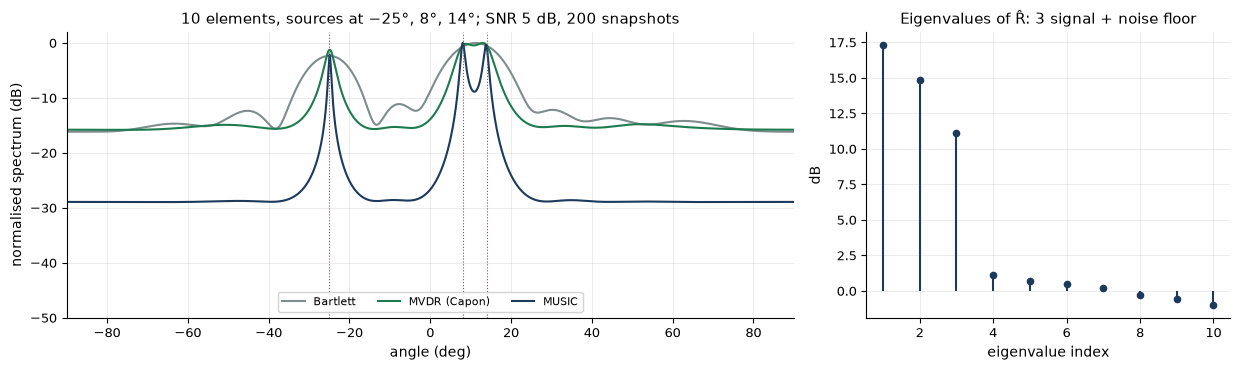

In [9]:
def doa_demo(sep=6.0, snr_db=5.0, K=200, N=10, coherent=False):
    r = np.random.default_rng(9)
    srcs = np.deg2rad([-25.0, 8.0, 8.0 + sep])
    A = cl.ula_steering(N, srcs)
    S = cn(r, (3, K)) * np.sqrt(lk.undb(snr_db))
    if coherent:
        S[2] = S[1] * np.exp(1j * 0.7)                       # a multipath copy of source 2
    X = A @ S + cn(r, (N, K))
    R = X @ X.conj().T / K
    th = np.deg2rad(np.linspace(-90, 90, 3601))
    a = cl.ula_steering(N, th)
    bart = np.real(np.sum(np.conj(a) * (R @ a), axis=0)) / N
    capon = 1 / np.real(np.sum(np.conj(a) * (np.linalg.inv(R) @ a), axis=0))
    ev, V = np.linalg.eigh(R)
    music = 1 / np.sum(np.abs(V[:, :N - 3].conj().T @ a) ** 2, axis=0)
    f, ax = lk.fig((12.5, 3.8), 1, 2, gridspec_kw=dict(width_ratios=[2, 1]))
    for p, col, lab in [(bart, lk.GRAY, "Bartlett"), (capon, lk.GREEN, "MVDR (Capon)"), (music, lk.NAVY, "MUSIC")]:
        ax[0].plot(np.rad2deg(th), lk.db(p / p.max()), color=col, label=lab)
    for s_ in np.rad2deg(srcs):
        ax[0].axvline(s_, color=lk.RED, ls=":", lw=0.8)
    ax[0].set_ylim(-50, 2); ax[0].set_xlim(-90, 90); ax[0].legend(fontsize=8, loc="lower center", ncol=3)
    ax[0].set_xlabel("angle (deg)"); ax[0].set_ylabel("normalised spectrum (dB)")
    ax[0].set_title(f"{N} elements, sources at −25°, 8°, {8 + sep:g}°; SNR {snr_db:g} dB, {K} snapshots" + (" (2 and 3 coherent)" if coherent else ""))
    ax[1].stem(np.arange(1, N + 1), lk.db(ev[::-1]), basefmt=" ")
    ax[1].set_xlabel("eigenvalue index"); ax[1].set_ylabel("dB"); ax[1].set_title("Eigenvalues of R̂: 3 signal + noise floor")
    lk.show(f)

lk.interact(doa_demo, sep=lk.slider(6, 1, 20, 0.5, "separation of sources 2 and 3 (deg)"), snr_db=lk.slider(5, -10, 30, 1, "SNR (dB)"),
            K=lk.choice([20, 50, 200, 1000], 200, "snapshots"), N=lk.choice([6, 10, 16, 32], 10, "elements"),
            coherent=lk.choice([False, True], False, "sources 2 and 3 coherent (multipath)"))

**What you should see.** With 6° separation and a 10-element array (beamwidth about 10°), Bartlett shows a single lump at 8–14°,
MVDR begins to split it, and MUSIC resolves two sharp peaks: super-resolution, from the eigenstructure of the covariance. The
eigenvalue plot has three large values (one per source) above a flat noise floor. Make sources 2 and 3 coherent (one a reflection
of the other) and the covariance loses rank: MUSIC and MVDR fail, which is why practical systems add spatial smoothing.

### Try it yourself 3.1
What is the broadside half-power beamwidth (degrees) of the 10-element λ/2 array, by Chapter 19's formula?

In [11]:
answer_3_1 = None
lk.check("3.1 HPBW of 10 elements (deg)", answer_3_1, 10.15, atol=0.1)

[TODO] 3.1 HPBW of 10 elements (deg): not attempted yet: replace the None with your answer

## 4. Beam management: SSB sweep and a Type I codebook

An NR millimetre-wave cell transmits its SS/PBCH blocks in a burst of up to 64 beams (8 below 6 GHz in case C), one beam per
block; the phone measures the reference signal received power (RSRP) of each and reports the best, and the base station
refines from there with CSI-RS. For data, the phone picks a precoder from a codebook: NR's **Type I single-panel** codebook is
built from oversampled DFT beams $\mathbf v_m = [1, e^{j2\pi m/(O_1N_1)}, \ldots]^T$, with a co-phasing term $\varphi \in \{1, j, -1, -j\}$
between the two polarisations: $\mathbf w = [\mathbf v_m;\ \varphi\mathbf v_m]/\sqrt{2N_1}$. Below: an 8-element base station
(per polarisation) and a phone at a chosen angle in a channel with a strong path and some scattering.

### Interactive: user angle and oversampling

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

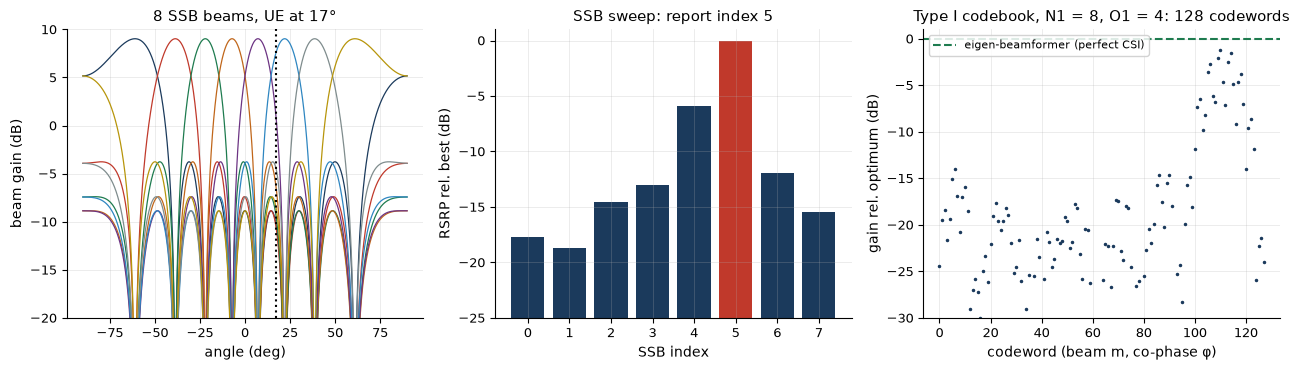

,
best SSB beam,5 (pointing 22.0°)
"best PMI: beam m, co-phase φ","m = 27, φ = -1"
codebook loss vs eigen-beamforming,-1.26 dB
PMI feedback bits,7


In [13]:
def beam_demo(ue_deg=17.0, O1=4, n_ssb=8, scatter_db=-10.0):
    N1 = 8
    r = np.random.default_rng(12)
    th = np.deg2rad(np.linspace(-90, 90, 1801))
    n = np.arange(N1)
    ssb_angles = np.rad2deg(np.arcsin(np.linspace(-1, 1, n_ssb + 1)[:-1] + 1 / n_ssb))
    W_ssb = cl.ula_steering(N1, np.deg2rad(ssb_angles)) / np.sqrt(N1)
    f, ax = lk.fig((13, 3.8), 1, 3)
    for k in range(n_ssb):
        ax[0].plot(np.rad2deg(th), lk.db(np.abs(W_ssb[:, k].conj() @ cl.ula_steering(N1, th)) ** 2), lw=0.9)
    ax[0].axvline(ue_deg, color="k", ls=":"); ax[0].set_ylim(-20, 10); ax[0].set_xlabel("angle (deg)"); ax[0].set_ylabel("beam gain (dB)")
    ax[0].set_title(f"{n_ssb} SSB beams, UE at {ue_deg:g}°")
    # channel: dual-polarised, strong LOS path + 4 scattered paths
    angs = np.r_[np.deg2rad(ue_deg), r.uniform(-np.pi / 3, np.pi / 3, 4)]
    gains = np.r_[1.0, np.full(4, np.sqrt(lk.undb(scatter_db) / 4))]
    pol = cn(r, (5, 2)) * np.array([[1.0, 0.3]])            # path-dependent polarisation coupling
    h = sum(g * np.r_[p[0] * a, p[1] * a] for g, p, a in zip(gains, pol, cl.ula_steering(N1, angs).T))
    rsrp = lk.db(np.abs(W_ssb.conj().T @ h[:N1]) ** 2 + np.abs(W_ssb.conj().T @ h[N1:]) ** 2)
    ax[1].bar(np.arange(n_ssb), rsrp - rsrp.max() + 25, bottom=-25, color=[lk.RED if i == np.argmax(rsrp) else lk.NAVY for i in range(n_ssb)])
    ax[1].set_ylim(-25, 1); ax[1].set_xlabel("SSB index"); ax[1].set_ylabel("RSRP rel. best (dB)"); ax[1].set_title(f"SSB sweep: report index {np.argmax(rsrp)}")
    best, cb_gain = None, []
    for m in range(N1 * O1):
        v = np.exp(1j * 2 * np.pi * n * m / (N1 * O1))
        for phi in (1, 1j, -1, -1j):
            w = np.r_[v, phi * v] / np.sqrt(2 * N1)
            g = np.abs(np.vdot(w, h)) ** 2
            cb_gain.append(g)
            if best is None or g > best[0]:
                best = (g, m, phi)
    opt = np.linalg.norm(h) ** 2
    ax[2].plot(lk.db(np.array(cb_gain) / opt), ".", ms=3, color=lk.NAVY)
    ax[2].axhline(0, color=lk.GREEN, ls="--", label="eigen-beamformer (perfect CSI)")
    ax[2].set_ylim(-30, 1); ax[2].set_xlabel("codeword (beam m, co-phase φ)"); ax[2].set_ylabel("gain rel. optimum (dB)")
    ax[2].legend(fontsize=8); ax[2].set_title(f"Type I codebook, N1 = {N1}, O1 = {O1}: {4 * N1 * O1} codewords")
    lk.show(f)
    lk.table([["best SSB beam", f"{np.argmax(rsrp)} (pointing {ssb_angles[np.argmax(rsrp)]:.1f}°)"],
              ["best PMI: beam m, co-phase φ", f"m = {best[1]}, φ = {best[2]}"],
              ["codebook loss vs eigen-beamforming", f"{lk.db(best[0] / opt):.2f} dB"],
              ["PMI feedback bits", f"{np.log2(4 * N1 * O1):.0f}"]], ["", ""])

lk.interact(beam_demo, ue_deg=lk.slider(17, -60, 60, 0.5, "UE angle (deg)"), O1=lk.choice([1, 2, 4, 8], 4, "oversampling O1"),
            n_ssb=lk.choice([4, 8, 16], 8, "SSB beams"), scatter_db=lk.slider(-10, -30, 5, 1, "scattered power rel. LOS (dB)"))

**What you should see.** The SSB beams tile the sector; the phone reports the beam whose RSRP is highest, here the one nearest
17°. The Type I codebook then gets within about 1 dB of eigen-beamforming when the channel is dominated by one path
(a DFT beam *is* the right precoder for a single plane wave), at the cost of 7 bits of feedback. Raise the scattered power to
0 dB: no single beam fits a rich channel, the loss grows, and that is what NR's Type II codebook (a combination of several
beams with amplitudes and phases) is for. With $O_1 = 1$ the user can fall between orthogonal beams and lose up to about 4 dB.

## 5. Hybrid precoding by orthogonal matching pursuit

A fully digital 64-element array needs 64 RF chains; a **hybrid** array has $N_{RF}$ chains feeding phase shifters:
$\mathbf F = \mathbf F_{RF}\mathbf F_{BB}$ with constant-modulus entries in $\mathbf F_{RF}$. El Ayach *et al.* (2014): millimetre-wave
channels have a few clusters, so the optimal SVD precoder lies near the span of a few steering vectors; **OMP** picks them greedily from
the dictionary of transmit steering vectors, then solves least squares for $\mathbf F_{BB}$. Chapter 19's simulation problem: a
64-element ULA, $N_{RF} = 4$, a sparse channel with five clusters, $N_s = 1, 2, 3$ streams, against unconstrained SVD precoding.

### Interactive: RF chains, clusters and rays

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

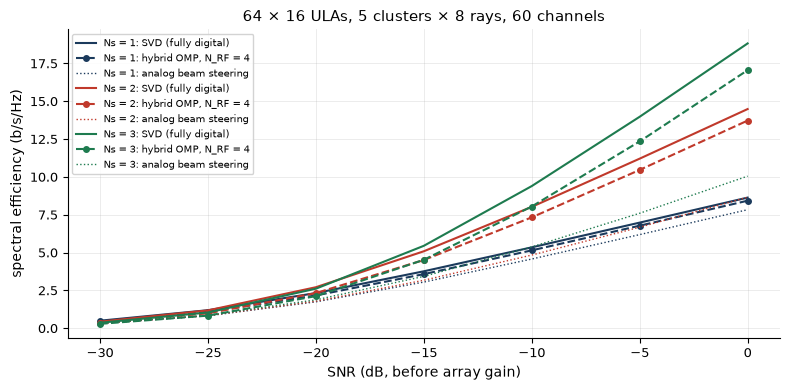

Ns,SVD at 0 dB,hybrid at 0 dB,hybrid / SVD (%)
1,8.64,8.43,97.63
2,14.49,13.73,94.74
3,18.82,17.06,90.61


In [15]:
def sparse_channel(Nt, Nr, n_cl, n_ray, r, spread_deg=5.0):
    th_c = r.uniform(-np.pi / 2, np.pi / 2, (2, n_cl))
    H = np.zeros((Nr, Nt), complex); At = []
    for c in range(n_cl):
        for _ in range(n_ray):
            tt = th_c[0, c] + np.deg2rad(spread_deg) * r.laplace() / np.sqrt(2)
            tr_ = th_c[1, c] + np.deg2rad(spread_deg) * r.laplace() / np.sqrt(2)
            at = cl.ula_steering(Nt, tt)[:, 0] / np.sqrt(Nt); ar = cl.ula_steering(Nr, tr_)[:, 0] / np.sqrt(Nr)
            H += cn(r, 1)[0] * np.outer(ar, at.conj()); At.append(at)
    return H * np.sqrt(Nt * Nr / (n_cl * n_ray)), np.array(At).T

def omp_precoder(Fopt, At, n_rf):
    Fres, idx = Fopt.copy(), []
    for _ in range(n_rf):
        k = int(np.argmax(np.sum(np.abs(At.conj().T @ Fres) ** 2, axis=1)))
        idx.append(k)
        Frf = At[:, idx]
        Fbb = np.linalg.lstsq(Frf, Fopt, rcond=None)[0]
        Fres = Fopt - Frf @ Fbb
        Fres /= np.linalg.norm(Fres)
    Fbb *= np.sqrt(Fopt.shape[1]) / np.linalg.norm(Frf @ Fbb)
    return Frf, Fbb

def se(H, F, snr, Ns):
    M = np.eye(H.shape[0]) + snr / Ns * H @ F @ F.conj().T @ H.conj().T
    return np.real(np.log2(np.linalg.det(M)))

def hybrid_demo(n_rf=4, n_cl=5, n_ray=8, trials=60):
    Nt, Nr = 64, 16
    r = np.random.default_rng(3)
    snrs = np.arange(-30, 1, 5.0)
    res = {}
    for Ns in (1, 2, 3):
        s_opt = np.zeros(len(snrs)); s_h = np.zeros(len(snrs)); s_beam = np.zeros(len(snrs))
        for _ in range(trials):
            H, At = sparse_channel(Nt, Nr, n_cl, n_ray, r)
            V = np.linalg.svd(H)[2].conj().T[:, :Ns]
            Frf, Fbb = omp_precoder(V, At, max(n_rf, Ns))
            Fh = Frf @ Fbb
            # analog-only beam steering: best Ns steering vectors of the dictionary, equal power
            k = np.argsort(np.sum(np.abs(H @ At) ** 2, axis=0))[::-1][:Ns]
            Fa = At[:, k] / np.linalg.norm(At[:, k]) * np.sqrt(Ns)
            for i, s_ in enumerate(snrs):
                g = lk.undb(s_)
                s_opt[i] += se(H, V, g, Ns); s_h[i] += se(H, Fh, g, Ns); s_beam[i] += se(H, Fa, g, Ns)
        res[Ns] = (s_opt / trials, s_h / trials, s_beam / trials)
    f, ax = lk.fig((8, 4))
    for Ns, col in zip((1, 2, 3), (lk.NAVY, lk.RED, lk.GREEN)):
        o, h_, b_ = res[Ns]
        ax.plot(snrs, o, "-", color=col, label=f"Ns = {Ns}: SVD (fully digital)")
        ax.plot(snrs, h_, "o--", color=col, ms=4, label=f"Ns = {Ns}: hybrid OMP, N_RF = {max(n_rf, Ns)}")
        ax.plot(snrs, b_, ":", color=col, lw=1, label=f"Ns = {Ns}: analog beam steering")
    ax.set_xlabel("SNR (dB, before array gain)"); ax.set_ylabel("spectral efficiency (b/s/Hz)"); ax.legend(fontsize=7, ncol=1)
    ax.set_title(f"64 × 16 ULAs, {n_cl} clusters × {n_ray} rays, {trials} channels")
    lk.show(f)
    lk.table([[Ns, res[Ns][0][-1], res[Ns][1][-1], 100 * res[Ns][1][-1] / res[Ns][0][-1]] for Ns in (1, 2, 3)],
             ["Ns", "SVD at 0 dB", "hybrid at 0 dB", "hybrid / SVD (%)"], fmt=".2f")

lk.interact(hybrid_demo, n_rf=lk.islider(4, 1, 8, 1, "RF chains N_RF"), n_cl=lk.islider(5, 1, 10, 1, "clusters"),
            n_ray=lk.islider(8, 1, 10, 1, "rays per cluster"), trials=lk.choice([30, 60, 200], 60, "channel draws"))

**What you should see.** With four RF chains, OMP's hybrid precoder is within a few per cent of fully digital SVD precoding for one
and two streams, and loses a little more for three: 4 chains instead of 64. Analog beam steering (one steering vector per stream,
no digital stage) is noticeably worse for several streams because its beams interfere. Cut the RF chains to $N_s$, or make the
channel rich (10 clusters × 10 rays), and the hybrid gap opens: the method relies on angular sparsity.

## 6. Line-of-sight MIMO

Without scattering, the MIMO channel between two small arrays is close to rank one, unless the arrays are large enough that the path lengths between elements differ
by a significant fraction of a wavelength. With two $N$-element arrays facing each other at range $R$, the channel columns are
orthogonal when $d_td_r = \lambda R/N$ (Chapter 19). At 80 GHz over 1 km with $N = 2$: $d = \sqrt{\lambda R/2} = 1.37$ m.

### Interactive: design range and frequency

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

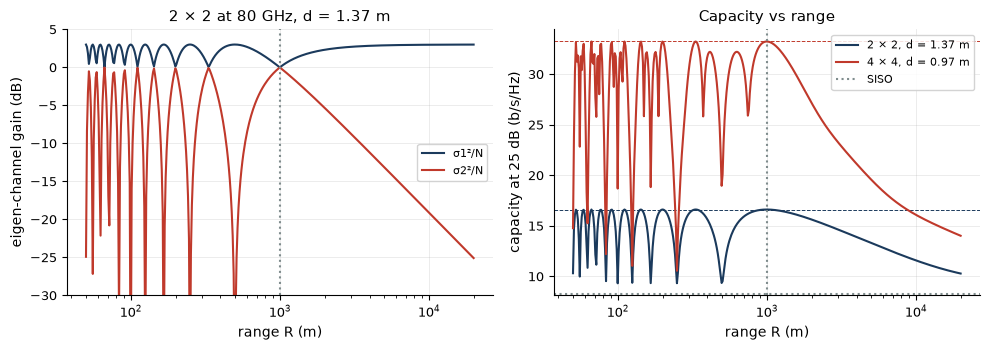

array,element spacing,array length
2 × 2,1.37 m,1.37 m
4 × 4,0.97 m,2.90 m


In [17]:
def los_channel(N, d, R, lam):
    y = (np.arange(N) - (N - 1) / 2) * d
    return np.exp(-2j * np.pi * np.sqrt(R ** 2 + np.subtract.outer(y, y) ** 2) / lam)

def los_demo(f_ghz=80.0, R0=1000.0, snr_db=25.0):
    lam = C0 / (f_ghz * 1e9)
    Rs = np.logspace(1.7, 4.3, 400)
    snr = lk.undb(snr_db)
    f, ax = lk.fig("row2", 1, 2)
    d2 = np.sqrt(lam * R0 / 2)
    sv = np.array([np.linalg.svd(los_channel(2, d2, R, lam), compute_uv=False) ** 2 / 2 for R in Rs])
    ax[0].semilogx(Rs, lk.db(sv[:, 0]), color=lk.NAVY, label="σ1²/N"); ax[0].semilogx(Rs, lk.db(sv[:, 1] + 1e-6), color=lk.RED, label="σ2²/N")
    ax[0].axvline(R0, color=lk.GRAY, ls=":"); ax[0].set_ylim(-30, 5); ax[0].legend(fontsize=8)
    ax[0].set_xlabel("range R (m)"); ax[0].set_ylabel("eigen-channel gain (dB)"); ax[0].set_title(f"2 × 2 at {f_ghz:g} GHz, d = {d2:.2f} m")
    for N, col in [(2, lk.NAVY), (4, lk.RED)]:
        d = np.sqrt(lam * R0 / N)
        C = [np.real(np.log2(np.linalg.det(np.eye(N) + snr / N * (H := los_channel(N, d, R, lam)) @ H.conj().T))) for R in Rs]
        ax[1].semilogx(Rs, C, color=col, label=f"{N} × {N}, d = {d:.2f} m"); ax[1].axhline(N * np.log2(1 + snr), color=col, ls="--", lw=0.7)
    ax[1].axhline(np.log2(1 + snr), color=lk.GRAY, ls=":", label="SISO"); ax[1].axvline(R0, color=lk.GRAY, ls=":")
    ax[1].set_xlabel("range R (m)"); ax[1].set_ylabel(f"capacity at {snr_db:g} dB (b/s/Hz)"); ax[1].legend(fontsize=8); ax[1].set_title("Capacity vs range")
    lk.show(f)
    lk.table([[f"{N} × {N}", f"{np.sqrt(lam * R0 / N):.2f} m", f"{(N - 1) * np.sqrt(lam * R0 / N):.2f} m"] for N in (2, 4)],
             ["array", "element spacing", "array length"], title=f"Optimal spacing for {R0:g} m at {f_ghz:g} GHz")

lk.interact(los_demo, f_ghz=lk.choice([18.0, 38.0, 80.0, 140.0], 80.0, "carrier (GHz)"), R0=lk.slider(1000, 100, 5000, 100, "design range (m)"),
            snr_db=lk.slider(25, 5, 40, 1, "SNR (dB)"))

**What you should see.** At the design range both eigen-channels are equally strong and the 2 × 2 capacity is twice SISO's; at
longer ranges the second eigenvalue fades (the arrays become small compared with the Fresnel zone) and the link falls back
towards one stream. At 80 GHz and 1 km the spacing is 1.37 m, practical on a tower; at 18 GHz it is 2.9 m. Add two
polarisations and an E-band LOS-MIMO radio carries four streams in one channel.

### Try it yourself 6.1
What element spacing (m) does a 2 × 2 LOS MIMO link need at 38 GHz over 2 km?

In [19]:
answer_6_1 = None
lk.check("6.1 LOS MIMO spacing, 38 GHz, 2 km (m)", answer_6_1, np.sqrt(C0 / 38e9 * 2000 / 2), atol=0.02)

[TODO] 6.1 LOS MIMO spacing, 38 GHz, 2 km (m): not attempted yet: replace the None with your answer

## Key takeaways
* A planar array's gain grows as $N$ and its EIRP as $N^2$; beamwidth $\approx 101.5°/N$; spacing above λ/2 invites grating lobes.
* Phase shifters squint across wide bands ($B \lesssim 0.9/T_a$); true time delay and digital beamforming do not.
* MUSIC and MVDR resolve sources closer than a beamwidth, but coherent sources defeat them without smoothing.
* NR beam management sweeps SSB beams and then refines with DFT codebooks; Type I is near-optimal for one dominant path.
* Hybrid precoding by OMP gets close to fully digital performance with a few RF chains in sparse channels.
* LOS MIMO works when $d_td_r = \lambda R/N$: big arrays, short wavelengths.

## Going further (hardware: USRP B200 / GNU Radio)
* The B200 has one transmit and one receive chain, but its sibling the B210 has two of each: with two antennas spaced λ/2 at
  2.4 GHz (6.2 cm), estimate the direction of a Wi-Fi access point from the phase difference between the channels (calibrate
  the inter-channel phase first with a common source).
* Move a single B200 receive antenna in λ/4 steps along a ruler and record the phase of a CW tone: a synthetic aperture that
  reproduces Section 3's Bartlett spectrum.

## Exercises
1. **(Warm-up)** Derive the 101.5°/N beamwidth from the array factor of a uniform λ/2 array.
2. **(Core)** Add spatial smoothing (average covariances of overlapping sub-arrays) to Section 3 and show that MUSIC resolves coherent sources.
3. **(Core)** Implement a sub-connected hybrid architecture (each RF chain drives 16 of the 64 elements) and compare with Section 5's fully connected OMP.
4. **(Stretch)** Add tower sway (a random displacement of a few cm) to Section 6 and measure the capacity loss.

In [21]:
lk.summary()

[good] Lab 29 finished in 2.7 s. Self-checks: 0 passed, 0 failed, 3 still to do.